**IMPORTING LIBRARIES AND LOADING FILES**

In [6]:
import pandas as pd
import numpy as np

file_path = ("C:/Users/khare/Downloads/EduPro Online Platform.xlsx")

# Check sheet names first
xls = pd.ExcelFile(r'C:/Users/khare/Downloads/EduPro Online Platform.xlsx')
print("Available sheets:", xls.sheet_names)

# Load all sheets (use exact names from above output)
df_courses = pd.read_excel(file_path, sheet_name="Courses")
df_teachers = pd.read_excel(file_path, sheet_name="Teachers")
df_transactions = pd.read_excel(file_path, sheet_name="Transactions")

print("Loaded successfully!")

Available sheets: ['Users', 'Teachers', 'Courses', 'Transactions']
Loaded successfully!


In [7]:
df_courses = pd.read_excel(r'C:/Users/khare/Downloads/EduPro Online Platform.xlsx', sheet_name="Courses")
df_teachers = pd.read_excel(r'C:/Users/khare/Downloads/EduPro Online Platform.xlsx', sheet_name="Teachers")
df_transactions = pd.read_excel(r'C:/Users/khare/Downloads/EduPro Online Platform.xlsx', sheet_name="Transactions")

In [8]:
print(df_courses.head())

  CourseID              CourseName CourseCategory CourseType   CourseLevel  \
0  CR00001           Python Basics    Programming       Paid      Beginner   
1  CR00002        Java Programming    Programming       Free  Intermediate   
2  CR00003       C++ for Beginners    Programming       Free      Beginner   
3  CR00004         Advanced Python    Programming       Free      Beginner   
4  CR00005  Full Stack Development    Programming       Free      Beginner   

   CoursePrice  CourseDuration  CourseRating  
0       472.28           11.00          4.74  
1         0.00           37.70          2.43  
2         0.00           19.53          3.85  
3         0.00           45.13          2.88  
4         0.00           28.68          1.28  


In [9]:

print(df_teachers.head())

  TeacherID         TeacherName  Age  Gender          Expertise  \
0   TC00001  Leonard Montgomery   44  Female      Cybersecurity   
1   TC00002            Jill Day   32  Female  Digital Marketing   
2   TC00003        Amber Torres   32    Male             Design   
3   TC00004        Kristi Scott   34  Female   Machine Learning   
4   TC00005      David Williams   34    Male            Finance   

   YearsOfExperience  TeacherRating  
0                  6           3.24  
1                  9           4.14  
2                  4           1.56  
3                  9           4.39  
4                  2           3.11  


In [10]:

print(df_transactions.head())

  TransactionID  UserID CourseID TransactionDate  Amount  PaymentMethod  \
0       TT00001  U00003  CR00016      2025-10-25     0.0         PayPal   
1       TT00002  U00003  CR00037      2025-01-13     0.0         PayPal   
2       TT00003  U00003  CR00019      2025-03-28     0.0  Bank Transfer   
3       TT00004  U00004  CR00048      2025-06-02     0.0  Bank Transfer   
4       TT00005  U00004  CR00060      2025-08-10     0.0         PayPal   

  TeacherID  
0   TC00040  
1   TC00040  
2   TC00040  
3   TC00040  
4   TC00042  


In [11]:
print(df_courses.shape)
print(df_teachers.shape)
print(df_transactions.shape)

(60, 8)
(60, 7)
(10000, 7)


In [12]:
df_courses.isnull().sum()

CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

In [13]:
df_courses['CourseRating'].fillna(df_courses['CourseRating'].mean(), inplace=True)
df_teachers['TeacherRating'].fillna(df_teachers['TeacherRating'].mean(), inplace=True)

C:\Users\khare\AppData\Local\Temp\ipykernel_21772\457025590.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_courses['CourseRating'].fillna(df_courses['CourseRating'].mean(), inplace=True)
C:\Users\khare\AppData\Local\Temp\ipykernel_21772\457025590.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [14]:
df_transactions['TransactionDate'] = pd.to_datetime(df_transactions['TransactionDate'])

In [15]:
enrollment_data = df_transactions.groupby('CourseID').agg(
    EnrollmentCount=('TransactionID','count'),
    CourseRevenue=('Amount','sum'),
    AvgRevenue=('Amount','mean')
).reset_index()

print(enrollment_data.head())

  CourseID  EnrollmentCount  CourseRevenue  AvgRevenue
0  CR00001              164       77453.92      472.28
1  CR00002              149           0.00        0.00
2  CR00003              173           0.00        0.00
3  CR00004              154           0.00        0.00
4  CR00005              166           0.00        0.00


**Data Merging**

In [16]:
# Remove extra spaces from columns
df_courses.columns = df_courses.columns.str.strip()
df_teachers.columns = df_teachers.columns.str.strip()
df_transactions.columns = df_transactions.columns.str.strip()

# Merge courses with transactions
merged = pd.merge(
    df_courses,
    df_transactions,
    on='CourseID',
    how='left'
)

# Merge teacher details
merged = pd.merge(
    merged,
    df_teachers,
    on='TeacherID',
    how='left'
)

# View output
merged.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TransactionID,UserID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00021,U00018,2025-03-24,472.28,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
1,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00061,U00117,2025-11-28,472.28,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00085,U00147,2025-11-14,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
3,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00090,U00152,2025-11-05,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
4,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00144,U00238,2025-08-24,472.28,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58


In [17]:
print(merged.shape)
print(merged.isnull().sum())
merged.head()

(10000, 20)
CourseID             0
CourseName           0
CourseCategory       0
CourseType           0
CourseLevel          0
CoursePrice          0
CourseDuration       0
CourseRating         0
TransactionID        0
UserID               0
TransactionDate      0
Amount               0
PaymentMethod        0
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TransactionID,UserID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00021,U00018,2025-03-24,472.28,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
1,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00061,U00117,2025-11-28,472.28,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00085,U00147,2025-11-14,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
3,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00090,U00152,2025-11-05,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97
4,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TT00144,U00238,2025-08-24,472.28,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58


Feature Engineering

In [18]:
df_courses['PriceBand'] = pd.cut(
    df_courses['CoursePrice'],
    bins=[0, 50, 150, 500],
    labels=['Low', 'Medium', 'High']
)

In [19]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'CourseCategory',
    'CourseType',
    'CourseLevel',
    'Expertise'
]

encoder = LabelEncoder()

for col in categorical_cols:
    merged[col] = encoder.fit_transform(merged[col].astype(str))

In [20]:
enrollment_data = df_transactions.groupby('CourseID').size().reset_index(name='EnrollmentCount')

enrollment_data.head()

,CourseID,EnrollmentCount
0,CR00001,164
1,CR00002,149
2,CR00003,173
3,CR00004,154
4,CR00005,166


In [21]:
merged = merged.merge(enrollment_data, on='CourseID', how='left')

merged.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TransactionID,UserID,...,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,EnrollmentCount
0,CR00001,Python Basics,9,1,1,472.28,11.0,4.74,TT00021,U00018,...,472.28,PayPal,TC00042,Yolanda Levine,49,Female,7,21,4.97,164
1,CR00001,Python Basics,9,1,1,472.28,11.0,4.74,TT00061,U00117,...,472.28,PayPal,TC00040,Kimberly Miller,49,Male,2,24,4.58,164
2,CR00001,Python Basics,9,1,1,472.28,11.0,4.74,TT00085,U00147,...,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,7,21,4.97,164
3,CR00001,Python Basics,9,1,1,472.28,11.0,4.74,TT00090,U00152,...,472.28,Credit Card,TC00042,Yolanda Levine,49,Female,7,21,4.97,164
4,CR00001,Python Basics,9,1,1,472.28,11.0,4.74,TT00144,U00238,...,472.28,PayPal,TC00040,Kimberly Miller,49,Male,2,24,4.58,164


In [22]:
print(merged.columns.tolist())

['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'TransactionID', 'UserID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating', 'EnrollmentCount']


In [23]:
X = merged[[
    'CourseCategory',
    'CourseType',
    'CourseLevel',
    'CoursePrice',
    'CourseDuration',
    'CourseRating',
    'TeacherRating',
    'YearsOfExperience'
]]

y = merged['EnrollmentCount']

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 8.993283372385221
R2 Score: 0.18547893256800851


In [36]:
from sklearn.ensemble import RandomForestRegressor
import pickle



rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('MAE:', mean_absolute_error(y_test, rf_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, rf_pred)))
print('R2:', r2_score(y_test, rf_pred))

MAE: 0.0
RMSE: 0.0
R2: 1.0


In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

             Feature  Importance
4     CourseDuration    0.353027
5       CourseRating    0.266839
0     CourseCategory    0.199330
3        CoursePrice    0.089633
2        CourseLevel    0.078089
1         CourseType    0.013081
6      TeacherRating    0.000000
7  YearsOfExperience    0.000000


C:\Users\khare\AppData\Local\Temp\ipykernel_21772\986884412.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


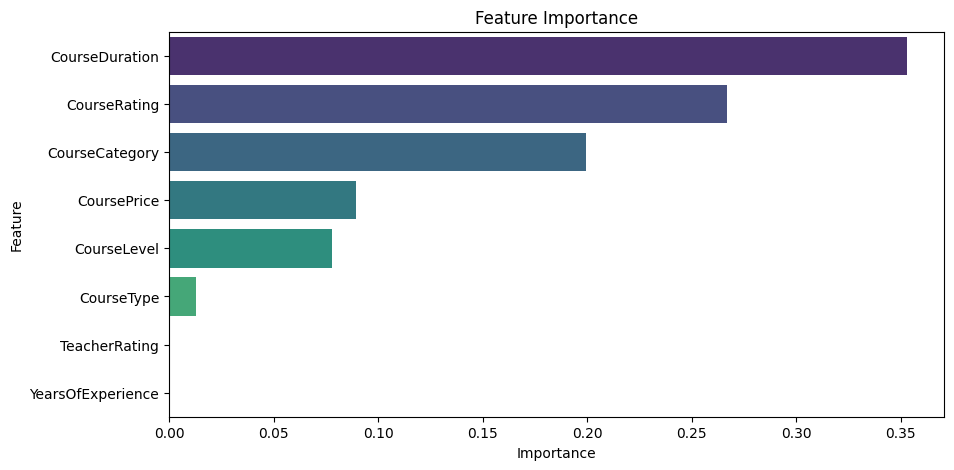

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='viridis'
)

plt.title('Feature Importance')
plt.show()

In [40]:
import joblib

joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [44]:
from sklearn.ensemble import RandomForestRegressor
import pickle


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X, y)


with open("rf_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully")

Model saved successfully


In [45]:
!pip install streamlit


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import streamlit as st

st.title("EduPro Enrollment Prediction App")

2026-05-12 12:07:02.123 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 12:07:02.810 
  command:

    streamlit run C:\Users\khare\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-12 12:07:02.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 12:07:02.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()